# Sequence to Sequence Learning with Neural Networks
This is a rewrite based on https://github.com/bentrevett/pytorch-seq2seq/blob/rewrite/1%20-%20Sequence%20to%20Sequence%20Learning%20with%20Neural%20Networks.ipynb

This only summarizes the content above in a way that I can easily refer or revise. Full information, please refer to the given link.


**This note still get stuck at train_model but script version running native works just fine. I will just move on**

    # Output:
    # The model has 13,898,501 trainable parameters
    # | Test Loss: 3.761 | Test PPL:  43.003 |
    # {'bleu': 0.1460770696582083,
    # 'precisions': [0.4938339920948617, 0.2063519313304721, 0.10093896713615023, 0.05036269430051814],
    # 'brevity_penalty': 0.9682616153519751,
    # 'length_ratio': 0.9687547863378771,
    # 'translation_length': 12650,
    # 'reference_length': 13058}

# Preparation of Data

Import any necessary libraries.

*   [PyTorch](https://pytorch.org/) for creating models
*   [spaCy](https://spacy.io/) for assisting in tokenization of data
*   [torchtext](https://github.com/pytorch/text) to provide helper functions (note: torchtext is deprecated from April 2024)
*   [Hugging Face's dataset](https://huggingface.co/docs/datasets/index) to load and manipulate our data
*   [Hugging Face's evaluate](https://huggingface.co/docs/evaluate/index) for calculating metrics







In [ ]:
!pip install datasets evaluate --upgrade
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
  Attempting uninstall: fsspec
    Found exi

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext ; torchtext.disable_torchtext_deprecation_warning()
from torchtext.vocab import build_vocab_from_iterator

import random
import spacy
import numpy as np

import datasets
import tqdm
import evaluate

## Import dataset
Will be using [Multi30k dataset](https://huggingface.co/datasets/bentrevett/multi30k)

Setting a seed ensures that random processes generate the same sequence of numbers every time you run the code.

In [ ]:
seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed) # Seed for CPU
torch.cuda.manual_seed(seed) # Seed for GPU
torch.backends.cudnn.deterministic = True # For reproducible results on CUDA GPUs

dataset = datasets.load_dataset("bentrevett/multi30k")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Print to test

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

Hugging Face Dataset: Create datasets of train, valid and test.

In [ ]:
train_data, valid_data, test_data = (
    dataset["train"],
    dataset["validation"],
    dataset["test"],
)

Print to test

In [ ]:
train_data[0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

## Tokenize

In [ ]:
# Next, load spaCy models that contain tozenizers
# python -m spacy download en_core_web_sm
# python -m spacy download de_core_news_sm
spacy_en = spacy.load("en_core_web_sm")
spacy_de = spacy.load("de_core_news_sm")

Example

In [ ]:
string = "What a lovely day it is today!"
[token.text for token in spacy_en.tokenizer(string)]

['What', 'a', 'lovely', 'day', 'it', 'is', 'today', '!']

Explain tokenize_example
- This function takes in an example from the Dataset object, applies the tokenizers English and German spaCy models,
trims the list of tokens to a maximum length, optionally converts each token to lowercase,
and then appends the start of sequence and end of sequence tokens to the beginning and end of the list of tokens.

- This function will be used with the map method from a Dataset,
which needs to return a dictionary containing the names of the features in each example where the outputs are stored.
- As the output feature names "en_tokens" and "de_tokens" are not already contained in the example (where we only have "en" and "de" features),
this will create two new features in each example.

@param:
example:    
spacy_en:         english tokens
spacy_de:         german tokens
max_length:     
lower:          if want to lower case all words
sos_token:      start of sequence token
eos_token:      end of sequence token

In [ ]:
def tokenize_example(example, spacy_en, spacy_de, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in spacy_en.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in spacy_de.tokenizer(example["de"])][:max_length]
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]
    return {"en_tokens": en_tokens, "de_tokens": de_tokens}

Explain `fn_kwargs`
- `fn_kwargs` used to contain keyword arguments for a function.
- it is used to map, apply a function to element of a data structure with additional parameters
that control how the function operates.


In [ ]:
max_length = 1_000
lower = True

sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "spacy_en": spacy_en,
    "spacy_de": spacy_de,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Print to test

In [ ]:
train_data[0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.',
 'en_tokens': ['<sos>',
  'two',
  'young',
  ',',
  'white',
  'males',
  'are',
  'outside',
  'near',
  'many',
  'bushes',
  '.',
  '<eos>'],
 'de_tokens': ['<sos>',
  'zwei',
  'junge',
  'weiße',
  'männer',
  'sind',
  'im',
  'freien',
  'in',
  'der',
  'nähe',
  'vieler',
  'büsche',
  '.',
  '<eos>']}

##Vocabulary




```
Explain Vocabulary
- sos_token = start of sequence ; <sos>
- eos_token = end of sequence ; <eos>

- Build the vocabulary for the source and target language.
- Vocabulary is used to associate each unique token in the dataset with an index.
- e.g. "hello"=1,  "world"=2. ["Hello", "world"] becomes [1, 2].

- We create vocabulary (one for each language) from dataset using build_vocab_from_iterator by torchtext.
- Which accepts iterator where each item is a list of tokens.
- It then counts up the number of unique tokens and assigns a numerical value.

- unk_token or <unk>
- VOCAB TRAINING ONLY FROM TRAINING SET and never from validation or test set.
- This prevents "information leakage", artificially inflating validation/test score

- What if a token exist in validation but not in training set?
- We need to replace these tokens with "unknown token" or "<unk>" even if tokens are different
- e.g. ["gilgamesh", "hates", "enkidu"] -> [0, 24, 0]

- Ideally model should be able to handle unknown tokens
BY LEARNING FROM CONTEXT AROUND THEM to make translations.
- The only way it can learn is if we have unknown tokens in trainning set.
- Hence in build_vocab_from_iterator, we use min_freq to NOT CREATE an index for tokens
which appears less than min_freq times in our training set.
- e.g. tokens that appear only twict in the whole training set will not get an index ->
replaced by unknown token index when converting tokens to indices

- pad_token or <pad>
- Specials argument to pass special tokens.
- These are tokens we want to add to vocab but not necessarily appear in tokenized examples.
- They will appear first in the vocab.
- These are added in batch. But that means they need to be same length
- Padding or <pad> tokens are used to equalize the tokens to the longest sentence in the batch.
- e.g. ["i", "love", "pizza"] and ["i", "hate", "music", "videos"]
becomes ["i", "love", "pizza", "<pad>"] and ["i", "hate", "music", "videos"]
before getting converted to indexes using the vocabulary.




In [ ]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

en_vocab = build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)
"""Side: get_itos
get_itos = get int to string, return a list of tokens
print(en_vocab.get_itos()[:10])
"""

de_vocab = build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

Print to test

In [ ]:
len(en_vocab), len(de_vocab) # (5893, 7853)

(5893, 7853)

In [ ]:
"""Side: get_itos
get_itos = get int to string, return a list of tokens
"""
en_vocab.get_itos()[:10]

['<unk>', '<pad>', '<sos>', '<eos>', 'a', '.', 'in', 'the', 'on', 'man']

Continue main: Defaulting unknown tokens' index to a set index

In [ ]:
# We make it so that the unk is truly index 0.
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]
unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token] # We get <pad> token for later use
en_vocab.set_default_index(unk_index) # Makes any unknown tokens into <unk> token
de_vocab.set_default_index(unk_index)

Side: `lookup_indices`, `lookup_tokens`
- Takes in a list of tokens and returns a list of indices

`tokens = ["i", "love", "watching", "crime", "shows"]`

`en_vocab.lookup_indices(tokens) # [956, 2169, 173, 0, 821]`

`en_vocab.lookup_tokens(en_vocab.lookup_indices(tokens))` # ['i', 'love', 'watching', '<unk>', 'shows']

In [ ]:
# Convert tokens to indices using the vocabularies
# and return the results into new en_ids and de_ids features
def numericalize_example(example, en_vocab, de_vocab):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])
    return {"en_ids": en_ids, "de_ids": de_ids}

In [ ]:
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}

train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Print to test

In [ ]:
print(', '.join(train_data[0].keys())) # Shows the key values of each train_data

en, de, en_tokens, de_tokens, en_ids, de_ids


In [ ]:
for key, value in train_data[0].items():
    print(f"{key}: {value}" )

en: Two young, White males are outside near many bushes.
de: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
en_tokens: ['<sos>', 'two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.', '<eos>']
de_tokens: ['<sos>', 'zwei', 'junge', 'weiße', 'männer', 'sind', 'im', 'freien', 'in', 'der', 'nähe', 'vieler', 'büsche', '.', '<eos>']
en_ids: [2, 16, 24, 15, 25, 778, 17, 57, 80, 202, 1312, 5, 3]
de_ids: [2, 18, 26, 253, 30, 84, 20, 88, 7, 15, 110, 7647, 3171, 4, 3]


Dataset class: `with_format`


- In order to use Dataset class to convert features to the correct type, need to be converted to PyTorch tensors first
- with_format method converts features indicated by the columns argument to a given type.
- data type = torch, column features = en_ids and de_ids.
- by default, with_format removes any features not in the list of features passed to columns,
- use output_all_column=True to mitigate.

In [ ]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

train_data = train_data.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

Print to test

In [ ]:
for key, value in train_data[0].items():
    print(f"{key}: {value}" )
print("\nen_ids type: ", type(train_data[0]["en_ids"]))

en_ids: tensor([   2,   16,   24,   15,   25,  778,   17,   57,   80,  202, 1312,    5,
           3])
de_ids: tensor([   2,   18,   26,  253,   30,   84,   20,   88,    7,   15,  110, 7647,
        3171,    4,    3])
en: Two young, White males are outside near many bushes.
de: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
en_tokens: ['<sos>', 'two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.', '<eos>']
de_tokens: ['<sos>', 'zwei', 'junge', 'weiße', 'männer', 'sind', 'im', 'freien', 'in', 'der', 'nähe', 'vieler', 'büsche', '.', '<eos>']

en_ids type:  <class 'torch.Tensor'>


##DataLoaders

Final step of Data Preparation is to create the data loaders.
-
- These can be iterated upon to return a batch of data
- Each batch being a dictionary containing the numericalized English and German sentences (+padding) as PyTorch tensors.
---

`def collate_fn(batch):`

First we need to create a function that collates or combines a batch of examples into a batch via `collate_fn`
1. `collate_fn` takes a "batch" as input (list of examples).
2. Then, separate out the English and German indices for each example in the batch.
3. Pass each one to the `pad_sequence` function.

`pad_sequence` takes a list of tensors, pads each one to the length of the longest tensor using the `padding_value` (which we set to `pad_index`, the index of our `<pad>` token)

returns a `[max_length, batch_size]` shaped tensor.
- `max_length` is length of longest tensor in batch
- `batch_size` is number of examples in batch

We put each tensors into a dictionary and return it.

---

`def get_collate_fn(pad_index):`
- takes in the padding token index and returns the `collate_fn` defined inside it.

**Closure**
- A technique to define a function inside another and returning it.
- This allows the nested funciton `collate_fn` to continually use the value `pad_index` without creating a class or using global variables.

In [ ]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

Next, we write function with gives us our data loaders creating using PyTorch's `DataLoader` class.

- `get_data_loader` is created using `Dataset`, batch size, padding token and boolean deciding should be shuffled.

- Batch size defines maximum amount of examples within a batch. If length of the dataset is not evenly divisible by batch size, then last batch will be smaller.

In [ ]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

Finally we create the Data Loader
- To reduce training time, we use largest batch size possible. When using a GPU, this will fit in GPU memory.
- **Shuffling** of data makes training more **stable** and potentially improves final performance, but needs to be done on training set.

In [ ]:
batch_size = 128

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

#Building the Model

##Encoder

A 2 layer LSTM. This `Encoder` module inherit from `torch.nn.Module` and uses `super().__init__()` as some boilerplate code.

@param
- `input_dim` - size/dimensionality of the one-hot vectors that will be input to the encoder. This is equal to the input(source) vocabulary size.
- `embedding_dim` - dimensionality or embedding layer. This layer converts the one-hot vectors into dense vectors with `embedding_dim` dimensions.
- `hidden_dim` - dimensionality of hidden and cell states.
- `n_layers` - number of layers in the RNN.
- `dropout` - amount of dropout to use. **This is a regularization parameter to prevent overfitting**.

Embedding Layer, LSTM and Dropout uses pre-defined module from `torch.nn.Embedding`, `torch.nn.LSTM` and `torch.nn.Dropout`. Check previous modules or PyTorch documentations.

`def forward():`
- First we pass the source sentence, _**X**_, which is converted to a _dense vector_ using `embedding` layer, and then `dropout` is applied.
- These embeddings are the npassed into the RNN.
- We pass a whole sequene to the RNN and it does RNN (LSTM).
- We do not pass in initial hidden or cell state to the RNN. This is because in the documentation, if no hidden/cell state is passed to the RNN, it will automatically create an initial hidden/cell state as a tensor of all zeros.

- The RNN returns: `output` (the top-layer hidden state for each time-step), `hidden` (long memory -- the final hidden state for each layer, stacked on top of each other) and `cell` (short memory -- final cell state for each layer, stacked on top of each other).

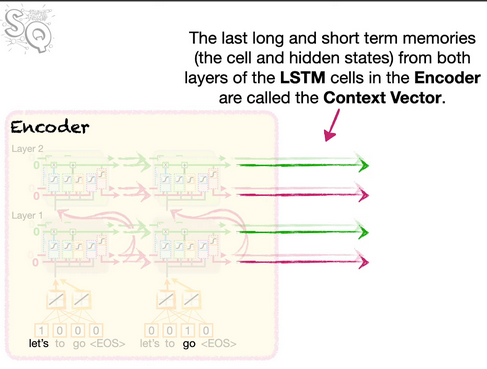

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src length, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src length, batch size, embedding dim]
        outputs, (hidden, cell) = self.rnn(embedded)
        # outputs = [src length, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # cell = [n layers * n directions, batch size, hidden dim]
        # outputs are always from the top hidden layer
        return hidden, cell

##Decoder

This is also a 2-layer LSTM.

The `Decoder` class does a single step of decoding; outputs a single token per time-step.

@param
- similar to `Encoder` but has `output_dim` instead. This is the size of vocabulary for the output/target language.
- There is an additional `Linear` layer (FCN, the categorizer) used to make predictions from the top layer hidden state.



- First layer receive a hidden and cell state from previous time step and feeds it through the LSTM with the current embedded token to produce a new hidden and cell state.
- Subsequent layers will use the hidden state from layer below.
1. Within the `forward` method, wwe accept a batch of input tokens, previous hidden states and previous cell states.
2. As we are only **decoding one token at a time**, the input tokens will always have a **sequence length of 1**.
3. Similar to encoder, we pass through an embedding layer and apply dropout.
4. Pass through an RNN and produce `output` (hidden state from top layer of RNN), new `hidden` state (long memory -- one for each layer), and a new `cell` state (short memory -- one per layer).
5. We then pass the `output` (after getting rid of sentence length dimension) through linear layer (FCN) to receive our prediction.
6. We then return the `prediction`, new `hidden` state and new `cell` state.

**Note**: as we have sequence length of 1, we could use `nn.LSTMCell`, instead of `nn.LSTM`,
- `nn.LSTM` is designed to handle a batch of inputs that are not necessarily in a sequence.
- `nn.LSTM` is a wrapper around potentially multiple cells.
- Using `nn.LSTMCell`, we don't need to `unsqueeze` to add a fake sequence length dimension, but we need one `nn.LSTMCell` per layer in the decoder to ensure each `nn.LSTMCell` receves the correct initial hidden state from the encoder.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell):
        # input = [batch size]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # cell = [n layers * n directions, batch size, hidden dim]
        # n directions in the decoder will both always be 1, therefore:
        # hidden = [n layers, batch size, hidden dim]
        # context = [n layers, batch size, hidden dim]
        input = input.unsqueeze(0)
        # input = [1, batch size]
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, embedding dim]
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        # output = [seq length, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # cell = [n layers * n directions, batch size, hidden dim]
        # seq length and n directions will always be 1 in this decoder, therefore:
        # output = [1, batch size, hidden dim]
        # hidden = [n layers, batch size, hidden dim]
        # cell = [n layers, batch size, hidden dim]
        prediction = self.fc_out(output.squeeze(0))
        # prediction = [batch size, output dim]
        return prediction, hidden, cell

##Seq2Seq

Seq2Seq model will handle
- receiving input/source sentence
- using encoder to produce context vector
- using decoder to produce predicted output/target sequence

The Seq2Seq model takes in an `Encoder`, `Decoder`, and a `device` (to place tensors on the GPU, if it exists).

- For this implementation, we have to ensure that the number of layers and hidden (and cells) dimensions are equal in the `Encoder` and `Decoder`.
- _This is not necessarily required_ (to have same number of layer or same hidden dimension sizes in a sequence-to-sequence model).
- However, if different number of layers, then need to figure out how to handle them.
- e.g. if encoder has 2 layers but decoder has 1 layer.
 - Do we average the two context vectors output by the decoder?
 - Do we pass both through a linear layer?
 - Do we only use context vector from highest level? etc.
- `forward` method takes the source sentence, target sentence and a teacher-forcing ratio.
- teacher-forcing ratio is used when training our model. It is an algorithm for training weights of RNN involving feeding observed sequence values (i.e. ground-truth samples) back into RNN after each step, thus forcing RNN to stay close to the ground-truth sequence.
- when decoding at each time-step, we predict the next token in the target sequence from the previous token decoded (watch StatQuest video for more info or refer to Decoder segment).
- With probability == teaching-forcing ratio, we use _actual ground truth_ next token in the sequence as the input to the decoder during the next time-step.
- With probability 1 - `teaching_forcing_ratio`, we use token that the model predicted previously as next input to the model, even if it is wrong in ground-truth sense.  

1. `forward` - create an `outputs` tensor that will store all of our predictions.
2. Feed the input/source sentence, `src`, into the encoder and receive out final hidden and cell states.
3. The first input to the decoder is start of sequence `<sos>` token. As our `trg` tensor already has the `<sos>` token appended (back when we tokenized the English sentence) we get y1 by slicing into it.
 - We know how long our target sentence should be (`trg_length`), so we loop that many times.
4. The **last token** input into the decoder is **one before the `<eos>` token.** !!**`<eos>` token is never input into the decoder.!!

During each iteration of the loop:
1. pass input, previous hidden and previous cell states into decoder.
2. receive a prediction, next hidden state and next cell state from decoder.
3. place our prediction in our tensor of predictions.
4. decide if we are going to use "teacher force"
 - (training) if we do, next `input` is ground-truth next token in the sequence
 - (not) if we don't, next `input` is the predicted next token in the sequence, which we get by doing an `argmax` over the output tensor.
5. Once we've made all of our predictions, we return our tensor full of predictions.

Note: our decoder loop starts at 1, not 0. This means 0th element of our `outputs` tensor remains all zero.

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        assert (
            encoder.hidden_dim == decoder.hidden_dim
        ), "Hidden dimensions of encoder and decoder must be equal!"
        assert (
            encoder.n_layers == decoder.n_layers
        ), "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio):
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if teacher_forcing_ratio is 0.75 we use ground-truth inputs 75% of the time
        batch_size = trg.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        # tensor to store decoder outputs
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        # last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)
        # hidden = [n layers * n directions, batch size, hidden dim]
        # cell = [n layers * n directions, batch size, hidden dim]
        # first input to the decoder is the <sos> tokens
        input = trg[0, :]
        # input = [batch size]
        for t in range(1, trg_length):
            # insert input token embedding, previous hidden and previous cell states
            # receive output tensor (predictions) and new hidden and cell states
            output, hidden, cell = self.decoder(input, hidden, cell)
            # output = [batch size, output dim]
            # hidden = [n layers, batch size, hidden dim]
            # cell = [n layers, batch size, hidden dim]
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1
            # input = [batch size]
        return outputs

#Training the Model

##Model Initialization

In [ ]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256
decoder_embedding_dim = 256
hidden_dim = 512
n_layers = 2
encoder_dropout = 0.5
decoder_dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    hidden_dim,
    n_layers,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    hidden_dim,
    n_layers,
    decoder_dropout,
)

model = Seq2Seq(encoder, decoder, device).to(device)

##Weight Initialization

In [ ]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)


model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(5893, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (fc_out): Linear(in_features=512, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

Count the number of parameters in the model

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 13,898,501 trainable parameters


##Optimizer

In [ ]:
optimizer = optim.Adam(model.parameters())

## Loss Function

The `CrossEntropyLoss` function calculates both the log softmax as well as the negative log-likelihood of our predictions.

Our loss function calculates the average loss per token, however by passing the index of the `<pad>` token as the `ignore_index` argument we ignore the loss whenever the target token is a padding token.



In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

##Training Loop

1. Set the model into "training mode" with `model.train()`.
 - This turns on `dropout` (and `batch normalization`, which is not implemented in this script) and then iterate through the data iterator. Decoder starts at 1.
2. At each iteration, get the source and target sentences from the batch, X and Y.
3. Zero the gradient calculated from the last batch.
4. Feed the source and target into the model to get the output.
5. As the loss function only works on 2d inputs with 1d targets we need to flatten each of them with `.view`.
6. Calculate the gradients with `loss.backward()`.
7. Clip the gradients to prevent them from exploding (a common issue in RNNs).
8. Update the parameters of our model by doing an optimizer step.
9. Sum the loss value to a running total.
10. Finally, return the loss that is averaged over all batches.

In [ ]:
def train_fn(
    model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        # output = [trg length, batch size, trg vocab size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        # output = [(trg length - 1) * batch size, trg vocab size]
        trg = trg[1:].view(-1)
        # trg = [(trg length - 1) * batch size]
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

##Evaluation Loop

Similar to training loop, except we are not updating parameters, no need to pass an optimizer or a clip value.

This is done via `model.eval()` which turns off dropout (and batch normalization).

We use the `with torch.no_grad()` block to ensure no gradients are calculated within the block. This reduces memory consumption and speeds things up.

The iteration loop is similar (without the parameter updates), **however we must ensure we turn teacher forcing off for evaluation**. This will cause the model to only use it's own predictions to make further predictions within a sentence, which mirrors hiow it would be used in deployment.

In [ ]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)
            # src = [src length, batch size]
            # trg = [trg length, batch size]
            output = model(src, trg, 0)  # turn off teacher forcing
            # output = [trg length, batch size, trg vocab size]
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            # output = [(trg length - 1) * batch size, trg vocab size]
            trg = trg[1:].view(-1)
            # trg = [(trg length - 1) * batch size]
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

##Model Training

- At each epoch, we check if model has achieved best validation loss.
 - If best validation obtained, save the parameters of our model `state_dict` in PyTorch.
 - Then, when we test the model, we use the saved parameters to achieve best validation loss.
 - We print both loss and perplexity at each epoch. _It is easier to see a change in perplexity than a change in loss as the numbers are much bigger.

In [ ]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5

best_valid_loss = float("inf")

# for epoch in tqdm.tqdm(range(n_epochs)):
for epoch in range(n_epochs):
    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device,
    )
    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        device,
    )
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "tut1-model.pt")
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

	Train Loss:   4.670 | Train PPL: 106.647
	Valid Loss:   4.767 | Valid PPL: 117.601
	Train Loss:   4.245 | Train PPL:  69.761
	Valid Loss:   4.555 | Valid PPL:  95.126


##Evaluating the Model

We load the parameters (`state_dict`) that give the model the best validation loss and run it on a test set to get test loss and perplexity.

In [ ]:
model.load_state_dict(torch.load("tut1-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

**_Note: Everytime you tweak your hyperparameters, you are slowly overfitting to the validation set. This can be done on the test set too. Hence, you should evaluate your model on your test set as few times as possible_**

**_Note: [BLEU](https://aclanthology.org/P02-1040.pdf) score is commonly used to score the model_**. BLEU score has a high correlation with human judgement.

To get the model's BLEU score on the test set.
1. The model translates every example from the test set via `translate_sentence` function.
2. Function first converts the input `sentence` into `tokens`, optionally lowercases each `token`, then append `sos_token` and `eos_token`.
3. Then it uses the vocabulary to numericalize the tokens into `ids` and converts these `ids` into a `tensor`, adding a "fake" batch dimension
4. Then passes the tensor through the `encoder` to get the `hidden` and `cell` states.
5. Then `decoder`, starting with `sos_token`, converting it into a tensor, passing it through `decoder`, getting `predicted_token`.
  - Append `predicted_token` to our list of `inputs` to the decoder.
  - If `predicted_token` is `<eos>` then stop decoding.
  - If not, continue decoding until `<eos>` or hit `max_output_length`.
6. Once stop decoding, convert inputs into `tokens` using the vocabulary and return them.

In [ ]:
def translate_sentence(
    sentence,
    model,
    spacy_en,
    spacy_de,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            tokens = [token.text for token in de_nlp.tokenizer(sentence)]
        else:
            tokens = [token for token in sentence]
        if lower:
            tokens = [token.lower() for token in tokens]
        tokens = [sos_token] + tokens + [eos_token]
        ids = de_vocab.lookup_indices(tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        hidden, cell = model.encoder(tensor)
        inputs = en_vocab.lookup_indices([sos_token])
        for _ in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, cell = model.decoder(inputs_tensor, hidden, cell)
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        tokens = en_vocab.lookup_tokens(inputs)
    return tokens

Test sample to test `translate_sentence` function.

In [ ]:
sentence = test_data[0]["de"]
expected_translation = test_data[0]["en"]

sentence, expected_translation

Main: call translate_sentence

In [ ]:
translation = translate_sentence(
    sentence,
    model,
    spacy_en,
    spacy_de,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [ ]:
translation

Note: The model does not translate examples in the training, validation and test set.

In [ ]:
sentence = "Ein Mann sitzt auf einer Bank."

translation = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

translation

Main: loop over `test_data` to be evaluated

In [ ]:
translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    for example in tqdm.tqdm(test_data)
]

#BLEU

To calculate BLEU, we use Hugging Face's `evaluate` library.

**_Note: It is recommended to use libraries for measuring metrics to ensure there are no bugs in your metric calculations and giving you potentially incorrect results._**

In [ ]:
bleu = evaluate.load("bleu")

**Notes about BLEU**

- BLEU expects predictions (predicted translations) to be strings
- and references (actual English sentences) to be a <u>list of sentences</u>.
- BLEU works if you have multiple correct sentences per predictions as there can have multiple ways to translate a sentence.


---

As we only have a single reference sentence, we can just wrap our target sentence in a list and convert our translations from a list of tokens into a string via joining them with whitespace inbetween and rid of `<sos>` and `<eos>`.

In [ ]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [ ]:
predictions[0], references[0]

We also need to define a function which tokenizes an input string. This will be used to calculate the BLEU score by comparing our predicted tokens against the reference tokens.

The `get_tokenize_fn` returns our `tokenizer_fn`, which uses our `spaCy` tokenizer and lowercases tokens if necessary.

In [ ]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [ ]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)

In [ ]:
tokenizer_fn(predictions[0]), tokenizer_fn(references[0][0])

Finally, we calculate the BLEU metric across our test set.

We pass our `predictions`, `references` and our `tokenizer_fn` to the `compute` method of the BLEU metric to get our results.

In [ ]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [ ]:
results